In [1]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True

using device: cuda


In [2]:
np.random.seed(3)

def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

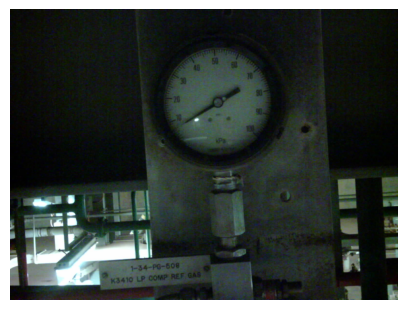

In [3]:
# Core
from pathlib import Path
# --- Config ---
base = "/mnt/projects-np/gauge-reading-poc/"

img_path = Path(f'{base}2025/10/08/08_F9_E0_90_82_40-21-02-20.jpeg')

image = Image.open(img_path)
image = np.array(image.convert("RGB"))
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis('off')
plt.show()


In [4]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

sam2_checkpoint = "../checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

mask_generator_2 = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=64,
    points_per_batch=128,
    pred_iou_thresh=0.7,
    stability_score_thresh=0.92,
    stability_score_offset=0.7,
    crop_n_layers=1,
    box_nms_thresh=0.7,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=25.0,
    use_m2m=True,
)

In [5]:
masks2 = mask_generator_2.generate(image)
len(masks2)

/home/wde.woodside.com.au/w94399/github_projects/sam2/sam2/sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (/home/wde.woodside.com.au/w94399/github_projects/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(


138

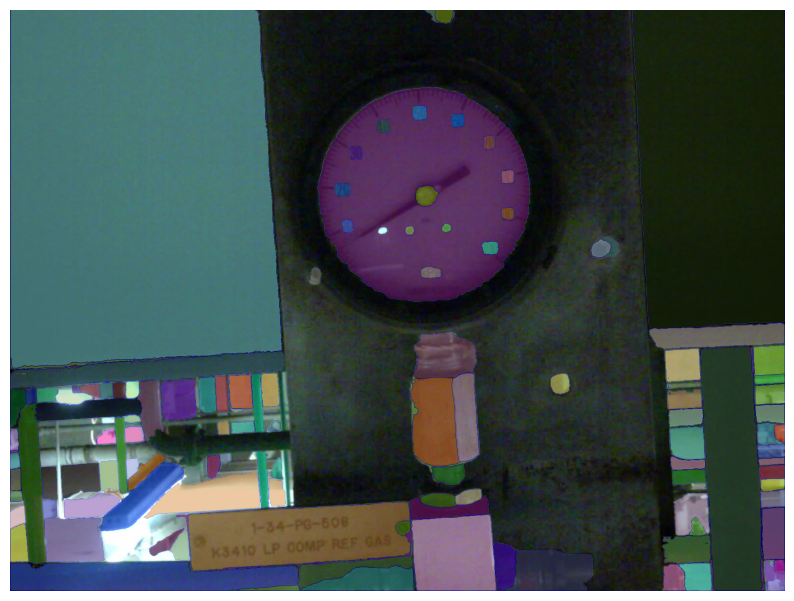

In [6]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_anns(masks2)
plt.axis('off')
plt.show() 

SAM-derived circle prior: (852.8, 383.5, 223.7)


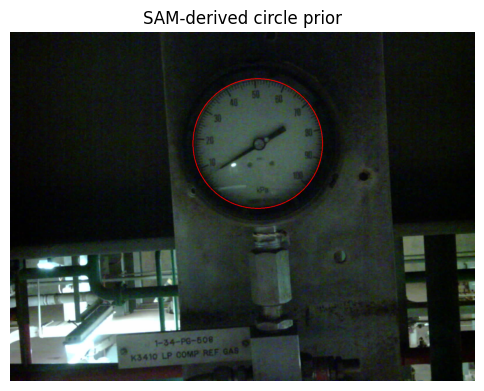

In [18]:
import cv2, numpy as np, matplotlib.pyplot as plt

H, W = image.shape[:2]
img_area = H * W

# Heuristics for circular candidates from SAM
rel_area_min, rel_area_max = 0.03, 0.60
circ_min = 0.62
border_margin = max(6, int(0.01 * min(H, W)))

# Collect contour points from the most circular, mid-sized SAM masks
cand_info = []
all_pts = []
for i, m in enumerate(masks2):
    seg = (m['segmentation'].astype(np.uint8) * 255)
    cnts, _ = cv2.findContours(seg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: 
        continue
    cnt = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    per  = cv2.arcLength(cnt, True) + 1e-6
    circ = (4*np.pi*area)/(per*per)

    x,y,w,h = cv2.boundingRect(cnt)
    touches_border = (x <= border_margin or y <= border_margin or
                      x+w >= W-border_margin or y+h >= H-border_margin)
    rel_area = area / (img_area + 1e-6)

    if touches_border: 
        continue
    if not (rel_area_min <= rel_area <= rel_area_max): 
        continue
    if circ < circ_min: 
        continue

    cand_info.append((circ, rel_area, i))
    all_pts.append(cnt.reshape(-1,2))

# If nothing passed, relax thresholds a bit
if len(all_pts) == 0:
    circ_min = 0.55
    for i, m in enumerate(masks2):
        seg = (m['segmentation'].astype(np.uint8) * 255)
        cnts, _ = cv2.findContours(seg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts: 
            continue
        cnt = max(cnts, key=cv2.contourArea)
        area = cv2.contourArea(cnt)
        per  = cv2.arcLength(cnt, True) + 1e-6
        circ = (4*np.pi*area)/(per*per)
        if circ >= circ_min:
            all_pts.append(cnt.reshape(-1,2))

# Estimate a circle from these points (use enclosing circle as a robust, simple fit)
assert len(all_pts) > 0, "No circular cues in SAM masks; try lowering circ_min or broadening rel_area bounds."
pts = np.vstack(all_pts).astype(np.float32)
(cx_prior, cy_prior), r_prior = cv2.minEnclosingCircle(pts)
cx_prior, cy_prior, r_prior = float(cx_prior), float(cy_prior), float(r_prior)

print("SAM-derived circle prior:", (round(cx_prior,1), round(cy_prior,1), round(r_prior,1)))

# Visual sanity check
overlay = image.copy()
cv2.circle(overlay, (int(cx_prior), int(cy_prior)), int(r_prior), (255,0,0), 2)
plt.figure(figsize=(6,6)); plt.imshow(overlay); plt.axis('off'); plt.title("SAM-derived circle prior"); plt.show()


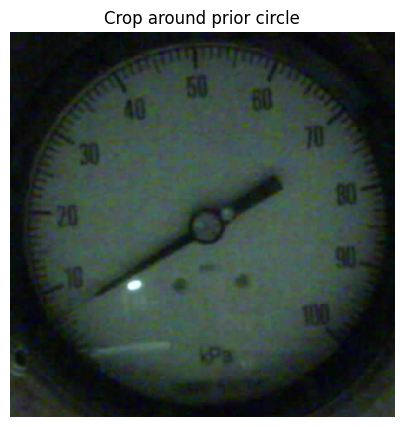

In [22]:
marg = int(0.05 * r_prior)  # 5% radius margin
x0 = max(0, int(cx_prior - r_prior - marg))
y0 = max(0, int(cy_prior - r_prior - marg))
x1 = min(W, int(cx_prior + r_prior + marg))
y1 = min(H, int(cy_prior + r_prior + marg))

crop = image[y0:y1, x0:x1]

plt.figure(figsize=(5,5))
plt.imshow(crop); plt.axis('off'); plt.title("Crop around prior circle")
plt.show()


In [23]:
mask_generator_inside = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=112,          # 96–128 if you need more detail
    points_per_batch=128,
    pred_iou_thresh=0.60,
    stability_score_thresh=0.88,
    stability_score_offset=0.70,
    crop_n_layers=2,
    crop_n_points_downscale_factor=2,
    box_nms_thresh=0.55,
    min_mask_region_area=150,     # raise to 300–800 to suppress specks
    use_m2m=True,
)

masks_inside = mask_generator_inside.generate(crop)
print("Inside masks:", len(masks_inside))


Inside masks: 201


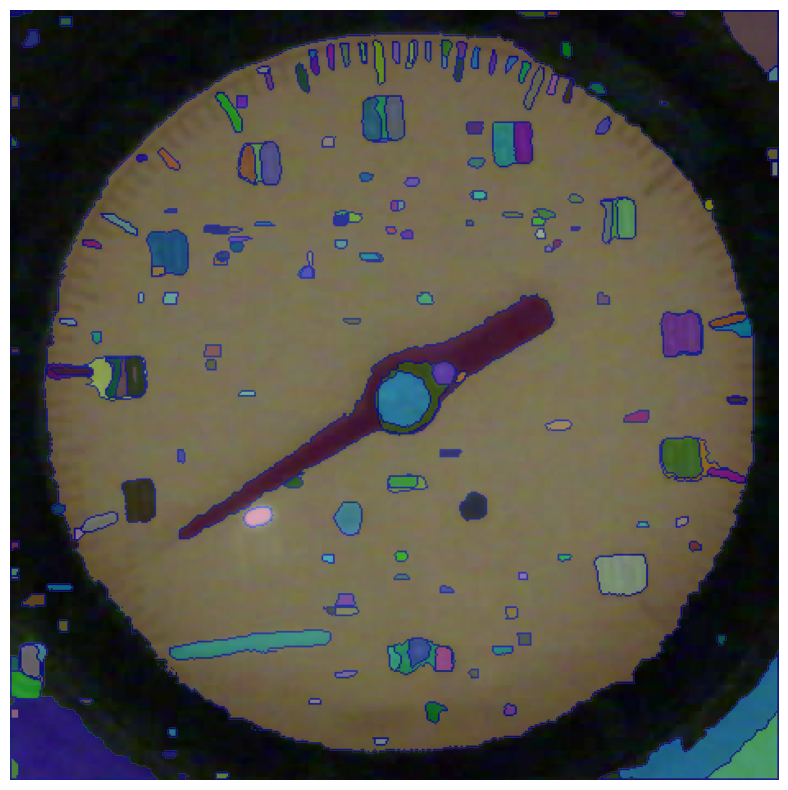

In [24]:
plt.figure(figsize=(10, 10))
plt.imshow(crop)
show_anns(masks_inside)
plt.axis('off')
plt.show() 